In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld
from scipy.interpolate import interp1d

# in this setup, we'll compare something similar to example 3 to a RADMC3D run.
# For simplicity, we'll add the inner rim so RADMC3D doesn't get abnormally high temperatures
# at the innermost cells

import radmc3dPy as r3d

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [2]:
d2g = 1e-3 # dust-to-gas ratio

wl, kabs, ksca, g_asy = fld.tools.parse_optool_file('opacities/dustkappa_0.1um.inp')

In [3]:
# === grid and star ===
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun, T=5772*u.K, wl=wl)
ri   = fld.grid.get_domain_with_ghosts(0.1, 10, Nx=128, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.35, np.pi/2, Nx=256)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

# === initialization of objects ===
# note that typically when calling a Dust object we should also provide a grain size and density,
# but this only really matters for the calculation of vertical settling, which we ignore here
Gas = fld.fluids.Gas(grid=grid, star=star, irradiation='gray', debug=False, name='basic')
Dust = fld.fluids.Dust(grid=grid, star=star, irradiation='freqdep', debug=False, name='basic',
                       kabs_wl=kabs, ksca_wl=ksca, g_wl=g_asy,
                       grain_rho=0*u.g/u.cm**3, grain_size=0.1*u.um) # rho=0 -> no settling

# === density and temperature ===
R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')
H_ = 0.03 * R_ ** 1.25
rho = 3e-10 * u.g/u.cm**3 * R_ ** -1.5 * np.exp(-0.5*(z_/H_)**2)
# clip the density in the inner regions to mimic the inner rim of the disk
rho *= 1e-6 + (1-1e-6) * 0.5 * (1 - np.tanh(-(R_-0.3)/0.01))

Gas.set_density(np.ones(grid.shape) * rho * 1e-100)
Dust.set_density(np.ones(grid.shape) * rho * d2g)
Gas.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.47)
Dust.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.47)

# === opacities and optical depth ===
Gas.enroll_kappaR(lambda f: 0.0 * u.cm**2/u.g)
Gas.enroll_kappaP(lambda f: 0.0 * u.cm**2/u.g)
Gas.enroll_kappaPstar(lambda f: 0.0 * u.cm**2/u.g)

# since we need to account for dust settling, we need a turbulence parameter
Dust.enroll_alpha(lambda f: 1e-1)

# === setup ===
Gas.setup()
Dust.setup()

Disk = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=True, debug=False, name='disk')

# === boundary conditions ===
# for this problem we simplify a bit by only simulating half the disk -> the x2 domain extends to π/2 and is reflective there
bounds, vals = [fld.grid.BOUNDARY_FIXEDVALUE] * 6, [fld.tools.T_to_Er(10*u.K)] * 6
vals[0] = fld.tools.T_to_Er(0.5 * 1550*u.K)
vals[1] = fld.tools.T_to_Er(50*u.K)
bounds[3] = fld.grid.BOUNDARY_REFLECTIVE # the value doesn't matter
Disk.declare_boundaries(bounds, vals)

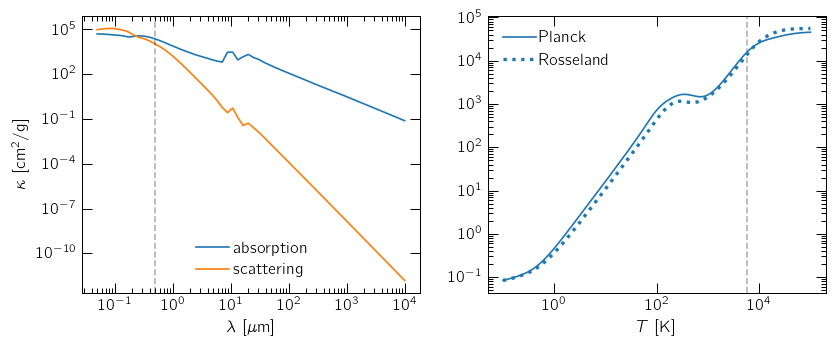

In [4]:
# check that the opacities make sense

fig, ax = plt.subplots(ncols=2, dpi=120, figsize=(8,3))

ax[0].plot(wl.to('um'), kabs.to('cm2/g'), label='absorption')
ax[0].plot(wl.to('um'), ksca.to('cm2/g'), label='scattering')

wl_star = 2.897771955e-3 * u.m * u.K / star.T
ax[0].axvline(wl_star.to_value('um'), ls='--', c='k', alpha=0.3)
ax[1].axvline(star.T.to_value('K'), ls='--', c='k', alpha=0.3)

T_opac = 1 * Dust.T_opac
# since kappa expects the fluid as an argument (but only uses fluid.tmp), make a dummy class that just contains tmp
class Foo: pass
foo = Foo(); foo.tmp = T_opac
ax[1].plot(T_opac, Dust.get_kappaP(foo), c='C0', ls='-', label='Planck')
ax[1].plot(T_opac, Dust.get_kappaR(foo), c='C0', ls=':', lw=2, label='Rosseland')
for axis in ax: axis.legend()
for axis in ax: axis.loglog()
ax[0].set_xlabel(r'$\lambda$ [$\mu$m]')
ax[1].set_xlabel(r'$T$ [K]')
ax[0].set_ylabel(r'$\kappa$ [cm${}^2$/g]')
plt.show()

In [5]:
# run the model
for _ in range(40): Disk.advance(dt=1e10 * u.yr)

RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iter

In [6]:
r = grid.x1[grid.act1].to_value('au')
theta = grid.x2[grid.act2]
phi = grid.x3[grid.act3]
mid = grid.mid

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in φ

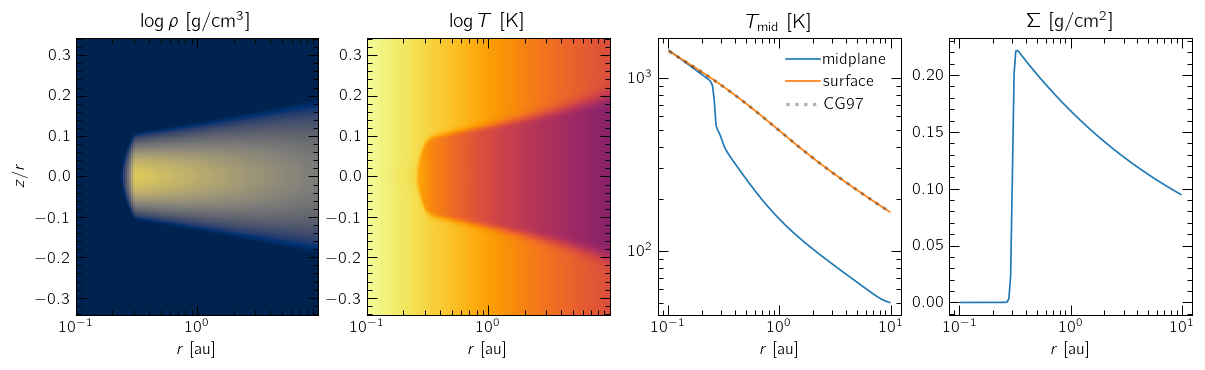

In [7]:
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Dust.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-17, vmax=-11)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Dust.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-17, vmax=-11)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# the Chiang and Goldreich formula also includes the ratio of opacities at Tstar/Tdisk
opac_factor = ((Dust.kappaPstar)/(fmt(Dust.kappaP)))[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [8]:
# now compute the density profile at this steady state
Disk.enforce_hydrostatic_equilibrium()

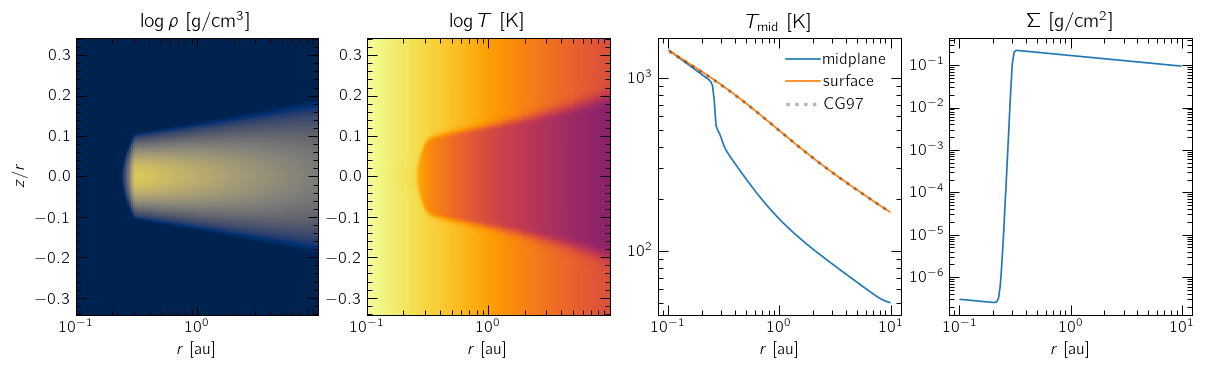

In [9]:
# and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Dust.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-17, vmax=-11)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Dust.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-17, vmax=-11)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[10], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# the Chiang and Goldreich formula also includes the ratio of opacities at Tstar/Tdisk
opac_factor = (Dust.kappaPstar/fmt(Dust.kappaP)[0]) ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()
ax[3].loglog()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [10]:
# run the model again
for _ in range(40): Disk.advance(dt=1e10 * u.yr)

RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iterations.
RadiativeEnvironment 'disk': Converged in 2 iter

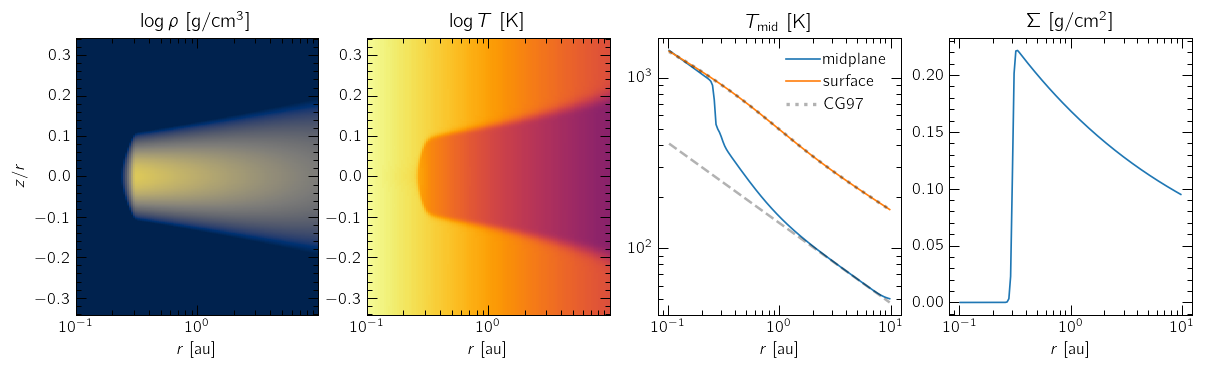

In [11]:
# and check the output again
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Dust.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-17, vmax=-11)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Dust.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-17, vmax=-11)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# there's only gas at the optically thin layers
opac_factor = fmt(Dust.kappaPstar/Dust.kappaP)[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')
ax[2].plot(r, 140 * r ** -0.47, ls='--', c='k', alpha=0.3, lw=1.5)

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [12]:
# we can now port this setup to RADMC3D. This will need you to have RADMC3D
# on your device if you want to test it yourself. But there's already a saved
# copy of the results of a radmc3d mctherm run with 1e8 photons in radmc_example!

In [13]:
import os
dirc = 'radmc/'
if not os.path.exists(dirc): os.mkdir(dirc)

rmc = fld.radmc_helper # a shorthand
# first create a wavelength array that is refined around 10um. This is optional though,
# you can just use star.wl
RMC_wl = rmc.get_wavelength_array(wl_min=wl.min(), wl_max=wl.max(), Npts=wl.size, Tstar=star.T)

# create a RADMC3D-compatible star object from the current star.
# This essentially just adds IO for RADMC3D
RMC_star = rmc.Star(dirc=dirc)
RMC_star.setup_from(Disk.star)
RMC_star.update_wavelengths(RMC_wl) # update with the new wavelength array

# same for the grid, it's the base class + RADMC3D IO
RMC_grid = rmc.Grid(dirc=dirc)
RMC_grid.setup_from(Disk.grid)

# now write the needed fields
rmc.write_wavelength_array(RMC_wl, dirc=dirc) # wavelength_micron.inp
RMC_star.write() # stars.inp
RMC_grid.write() # amr_grid.inp
rmc.write_density_array(rho=[Gas.rho[grid.active], Dust.rho[grid.active]], dirc=dirc) # dust_density.binp
rmc.write_opacity_handle(names=['flat', '0.1um'], dirc=dirc) # dustopac.inp
rmc.write_control_file(dirc=dirc, extra=True, nphot=int(1e7)) # radmc3d.inp
# if using a nonzero gas opacity, we also need to write its opacity!
# Currently only supports constant values, and kappaP = kappaPstar
rmc.write_flat_opacities(RMC_wl, Gas.get_kappaP(Gas), dirc=dirc)
_ = os.system(f'cp opacities/dustkappa_0.1um.inp {dirc}/') # copy the dust opacities we used above

# not actually used here, but if you want to make a quick image with RADMC3D and need
# temperatures, you can just create them in RADMC3D format using the pyFLD output:
# rmc.write_temperature_array(tmp=[Gas.tmp[grid.active], Dust.tmp[grid.active]], dirc=dirc)

: No grid parameters provided. Created an empty Grid object. Use setup_from() or read_from_file() to set up the grid.


In [14]:
# next, we need to open that directory in the terminal and run:
# radmc3d mctherm
# This can take a while. On my laptop it took about 10 minutes.
# In the meantime, you can always just read the example, or just run the above with fewer photons.

In [15]:
# now let's read the output.
# Change to dirc='radmc_example' to see the same model at 1e8 photons.
# rmc_rho, rmc_tmp = rmc.read_and_format_radmc_data(dirc=dirc)
rmc_rho, rmc_tmp = rmc.read_and_format_radmc_data(dirc='radmc_example')

rmc_rho = rmc_rho[1,0] # species 1 (dust), phi cell 0 (only)
rmc_tmp = rmc_tmp[1,0] # same
py_rho = 1 * fmt(Dust.rho).to('g/cm3')
py_tmp = 1 * fmt(Dust.tmp).to('K')

Reading amr_grid.inp
Reading wavelength_micron.inp
Reading dust_density.binp
Reading dust_temperature.bdat


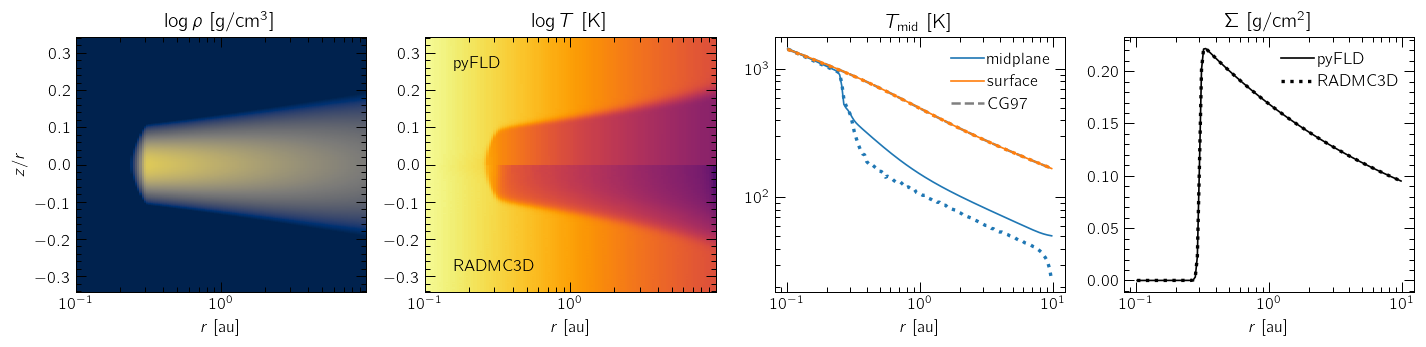

In [16]:
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)

rho_kwargs = dict(cmap=plt.cm.cividis, vmin=-17, vmax=-11)
tmp_kwargs = dict(cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[0].pcolormesh(r, np.cos(theta), np.log10(py_rho.to_value('g/cm3')), **rho_kwargs)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(rmc_rho.to_value('g/cm3')), **rho_kwargs)
ax[1].pcolormesh(r, np.cos(theta), np.log10(py_tmp.to_value('K')), **tmp_kwargs)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(rmc_tmp.to_value('K')), **tmp_kwargs)
ax[2].plot(r, py_tmp.to_value('K')[mid], label='midplane', c='C0')
ax[2].plot(r, py_tmp.to_value('K')[0], label='surface', c='C1')
ax[2].plot(r, rmc_tmp.to_value('K')[mid], c='C0', ls=':', lw=2)
ax[2].plot(r, rmc_tmp.to_value('K')[0], c='C1', ls=':', lw=2)
ax[3].plot(r, (fmt(Dust.rho * grid.dz)).sum(0).to_value('g/cm2'), c='k', label='pyFLD')
rmc_Sigma = (rmc_rho * grid.dz[grid.act2,grid.act1]).sum(0)
ax[3].plot(r, rmc_Sigma.to_value('g/cm2'), c='k', ls=':', lw=2, label='RADMC3D')

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

opac_factor = ((Dust.kappaPstar)/(fmt(Dust.kappaP)))[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls='--', c='k', alpha=0.5, lw=1.5, label='CG97', zorder=0)

ax[2].legend()
ax[3].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

ax[1].text(0.1, 0.9, 'pyFLD', transform=ax[1].transAxes, ha='left', va='center')
ax[1].text(0.1, 0.1, 'RADMC3D', transform=ax[1].transAxes, ha='left', va='center')

fig.tight_layout()
plt.show()

In [17]:
# optically thin temperatures are captured pretty much exactly from both codes,
# but pyFLD struggles a bit with the midplane temperature since radiation is gray.
# This is quite in line with other gray FLD codes (~30% error).
# Maybe a future upgrade to pyFLD that solves multiband radiation could solve that...
# Also worth noting that the outer boundary condition in pyFLD yields a better temperature
# than RADMC3D, simply because there's no such thing as boundary conditions in RADMC3D.
# Let's zoom in to the midplane to quantify the differences.

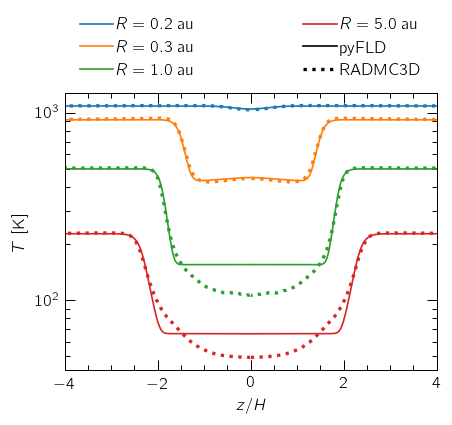

In [18]:
fig, ax = plt.subplots(dpi=120, figsize=(4,3))

for idx, r_target in enumerate([0.2, 0.3, 1, 5]):
    r_idx = np.argmin(np.abs(r-r_target))
    c = f'C{idx}'
    h_ = 0.023 * r_idx ** (0.5*(1-0.47))
    ax.plot(np.cos(theta) / h_, py_tmp[:, r_idx], c=c, ls='-', label=r'$R = %.1f$ au'%r_target)
    ax.plot(np.cos(theta) / h_, rmc_tmp[:, r_idx], c=c, ls=':', lw=2)
    ax.plot(-np.cos(theta) / h_, py_tmp[:, r_idx], c=c, ls='-')
    ax.plot(-np.cos(theta) / h_, rmc_tmp[:, r_idx], c=c, ls=':', lw=2)

ax.plot(np.nan, np.nan, ls='-', c='k', label='pyFLD')
ax.plot(np.nan, np.nan, ls=':', lw=2, c='k', label='RADMC3D')

ax.set_xlim(-4, 4)
ax.legend(bbox_to_anchor=[0,1,1,1], ncol=2, mode='expand', loc='lower left')

ax.set_yscale('log')
ax.set_ylabel(r'$T$ [K]')
ax.set_xlabel(r'$z/H$')

plt.show()

In [19]:
# Since pyFLD is gray, it recovers a flat temperature profile within the disk,
# while RADMC3D has a bowl-shaped structure since it's frequency-dependent.